## IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

2026-05-19 17:16:51.446888: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779211011.474483     475 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779211011.483441     475 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779211011.507716     475 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779211011.507737     475 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779211011.507739     475 computation_placer.cc:177] computation placer alr

## Getting all directory name

In [2]:
os.listdir('/kaggle/input/competitions/birdclef-2026')

['sample_submission.csv',
 'taxonomy.csv',
 'train_audio',
 'train_soundscapes_labels.csv',
 'train_soundscapes',
 'train.csv',
 'recording_location.txt',
 'test_soundscapes']

In [3]:
df_train=pd.read_csv('/kaggle/input/competitions/birdclef-2026/train.csv')

In [4]:
df_train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  object 
 6   common_name       35549 non-null  object 
 7   class_name        35549 non-null  object 
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  object 
 10  license           35549 non-null  object 
 11  rating            35549 non-null  float64
 12  url               35549 non-null  object 
 13  filename          35549 non-null  object 
 14  collection        35549 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 4.1+ MB


In [6]:
folders=['sample_submission.csv',
 'taxonomy.csv',
 'train_audio',
 'train_soundscapes_labels.csv',
 'train_soundscapes',
 'train.csv',
 'recording_location.txt',
 'test_soundscapes']

# Testing on one audio file

In [7]:
test_audio='/kaggle/input/competitions/birdclef-2026/train_audio/24279/iNat125223.ogg'

# GETTING NUMPY ARRAY IN DATA FOR VISUALIZING THE SIGNALS USING LIBROSA

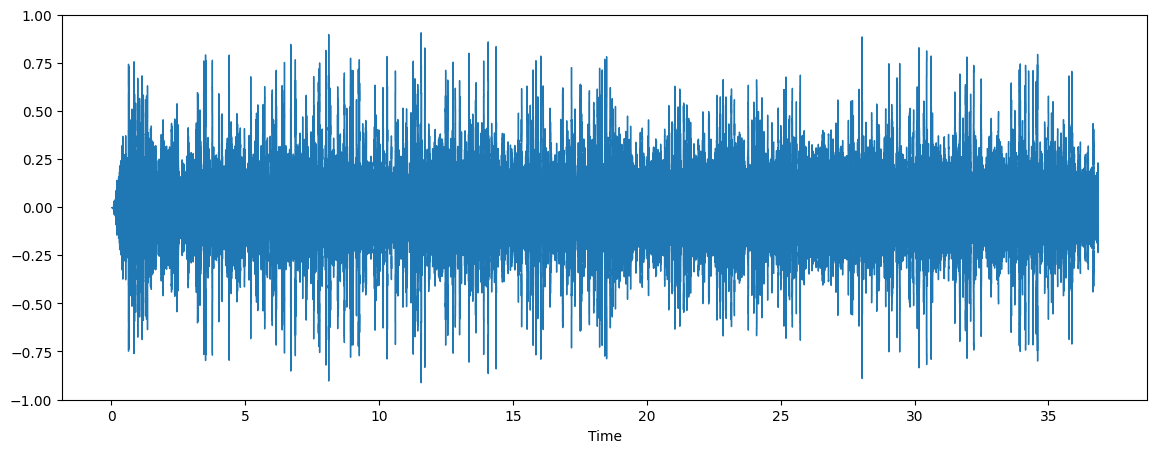

In [8]:
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(test_audio)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(test_audio)

# Spectrogram - Picture of Sound
## STFT- short time fourier transform
1. takes small chunk
2. finds frequencies inside chunk
3. moves slightly forward
4. repeats
``frame_length=320`` Analyze 320 audio samples at one time
``frame_step=32`` Means take 32 samples and then move forward

## After these steps we would have complex number 
### Because Fourier transform stores:
1. magnitude
2. phase
``tensorflow.abs(spectrogram)`` convert complex numbers into magnitude values like ``3+2j = 3.6`` WE GET THIS BY ``abs(3+2j) = sqrt(3² + 2²)``

## At last we expanded the dimension
### Because CNN require height,width,channel 
BEFORE ``(125,123) - > (125,123,1)``

In [9]:
spectrogram=tf.signal.stft(data,frame_length=320,
                                 frame_step=32)
spectrogram=tf.abs(spectrogram)
spectrogram=tf.expand_dims(spectrogram,axis=2)

I0000 00:00:1779211027.631482     475 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779211027.636659     475 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Picture of Spectrogram

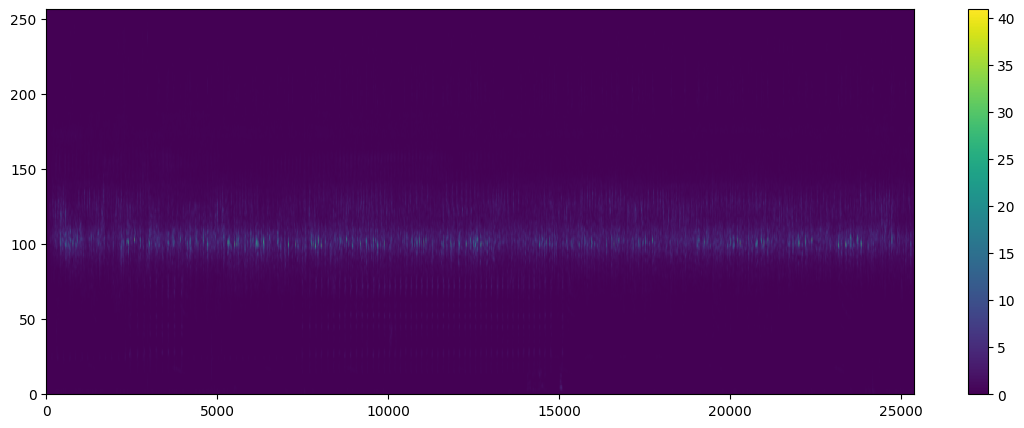

In [10]:
plt.figure(figsize=(14,5))

plt.imshow(
    tf.transpose(spectrogram)[0],
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.show()

# Load the file
### Converting the audio file into signal array

In [11]:
# def load_audio(filename):
#     # if hasattr(filename, 'item'):
#     #     filename = filename.item()
#     data,sample_rate=librosa.load(filename,
#                                   sr=16000,
#                                   mono=True)
#     return data
def load_audio(filename):
    # 1. If it's a TensorFlow tensor, extract its numpy bytes value
    if hasattr(filename, 'numpy'):
        filename = filename.numpy()
        
    # 2. If it's in bytes format (b'/path/...'), decode it to a clean Python string
    if isinstance(filename, bytes):
        filename = filename.decode('utf-8')
        
    # 3. Now librosa can read the clean path string perfectly
    data, sample_rate = librosa.load(filename, sr=16000, mono=True)
    return data

## Preprocesing
1. It takes audio file convert audio to signal array
2. Then it crop first 5 sec of audio and rest is dumpped
3. If the size of audio was less then 5 sec the remaining space is filled with zeros
4. Converting array into spectrogram

In [12]:
# def preprocess(filename,label):
#     data=load_audio(filename)
    
#     if len(data)<16000:
#         spectrogram=tf.zeros([2491,257,1],dtype=tf.float32)
#         return spectrogram,label
        
#     data=data[:80000]
    
#     pad_length = 80000 - tf.shape(data)[0]  # how many zeros needed
#     zero_padding = tf.zeros([pad_length], dtype=tf.float32)
    
#     data=tf.concat([data,zero_padding],0)
#     spectrogram=tf.signal.stft(data,frame_length=320,
#                                  frame_step=32)
    
#     spectrogram=tf.abs(spectrogram)
#     spectrogram=tf.expand_dims(spectrogram,axis=2)

#     return spectrogram,label

def preprocess(filename, label):
    # 1. Safely load audio dynamically inside the TensorFlow graph
    [data,] = tf.py_function(load_audio, [filename], [tf.float32])
    data.set_shape([None]) # Tell TF it's a 1D signal array
    
    # 2. Set target sample window: 5 seconds @ 16kHz = 80,000 samples
    target_samples = 80000
    signal_len = tf.shape(data)[0]
    
    # 3. Uniform pad or clip so EVERY file has an identical shape
    if signal_len < target_samples:
        pad_length = target_samples - signal_len
        zero_padding = tf.zeros([pad_length], dtype=tf.float32)
        data = tf.concat([data, zero_padding], axis=0)
    else:
        data = data[:target_samples]
        
    # 4. Generate the Spectrogram (Output shape: 2491, 257, 1)
    spectrogram = tf.signal.stft(data, frame_length=512, frame_step=64)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=-1) 
    
    return spectrogram, label

In [13]:
df=df_train[['primary_label','filename']]
path='/kaggle/input/competitions/birdclef-2026/train_audio/'
df.loc[:,'filename']=path+df.loc[:,'filename']

### Checking the audio files, max time, min time and mean time for preprocessing

In [14]:
!pip install mutagen

In [15]:
import os
from concurrent.futures import ThreadPoolExecutor
from mutagen.oggvorbis import OggVorbis

TARGET_SR = 16000  
all_files = df['filename'].tolist()

def get_audio_length(file_path):
    try:
        audio = OggVorbis(file_path)
        # audio.info.length gives duration in seconds
        # Multiply by target sample rate to get the sample length
        return int(audio.info.length * TARGET_SR)
    except Exception as e:
        return 0

# Use multithreading to read headers in parallel
with ThreadPoolExecutor() as executor:
    lengths = list(executor.map(get_audio_length, all_files))

# Filter out any failed reads (0) if necessary
lengths = [l for l in lengths if l > 0]

In [16]:
print(f'MEAN Size of audio : {tf.math.reduce_mean(lengths)/16000} sec')
print(f'MIN Size of audio  : {tf.math.reduce_min(lengths)/16000} sec')
print(f'MAX Size of audio  : {tf.math.reduce_max(lengths)/16000} sec')

MEAN Size of audio : 34.8825625 sec
MIN Size of audio  : 0.008 sec
MAX Size of audio  : 6881.097 sec


In [17]:
df.shape

(35549, 2)

## Encoding the labels so that the labels can be feeded to the model

In [18]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
df.loc[:,'primary_label']=labelencoder.fit_transform(df.loc[:,'primary_label'])

In [19]:
X=df['filename']
y=df['primary_label']

## Splitting the complete data in training set and test set

In [20]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(f'The shape of x_train is {x_train.shape} and shape of y_train is {y_train.shape}')
print(f'The shape of x_test is {x_test.shape} and shape of y_test is {y_test.shape}')

The shape of x_train is (28439,) and shape of y_train is (28439,)
The shape of x_test is (7110,) and shape of y_test is (7110,)


# DATA PREPROCESSING BEFORE TRAINING FOR FASTER EXECUTION
### Here the data from train and test is taken and some processing is done on it like :
1. Shuffling the data: Shuffles the file paths safely so the model learns unbiased patterns.

2. Map the data from preprocessing: Applies the ``preprocess`` function to convert raw audio paths into spectrograms in parallel.

3. Batching the data: Groups the data into packets of 16 samples to feed the model efficiently without crashing the memory.

4. Putting the loaded data in cache in hdd: Keeps the processed spectrograms in memory (RAM) for lightning-fast retrieval in the next epochs.

5. Using prefetch: Asynchronously prepares the next batch in the CPU while the GPU is training on the current batch.

In [21]:
AUTOTUNE=tf.data.AUTOTUNE
train_data=tf.data.Dataset.from_tensor_slices((x_train.tolist(),y_train.tolist()))
test_data=tf.data.Dataset.from_tensor_slices((x_test.tolist(),y_test.tolist()))

train_loader=(
    train_data.shuffle(buffer_size=1000)
    .map(preprocess,num_parallel_calls=AUTOTUNE)
    .batch(16)
    # .cache('/kaggle/working/train_cache')
    .prefetch(buffer_size=AUTOTUNE)
)

test_loader=(
    test_data
    .map(preprocess,num_parallel_calls=AUTOTUNE)
    .batch(16)
    .prefetch(buffer_size=AUTOTUNE)
)

In [22]:
classification_num=len(os.listdir('/kaggle/input/competitions/birdclef-2026/train_audio'))
classification_num

206

In [31]:
# 1. Pipeline se exactly 1 batch (16 images aur 16 labels) nikalen
for images_batch, labels_batch in train_loader.take(1):
    # 2. Batch ki dimensions print karein
    print("Full Batch Shape    :", images_batch.shape) 
    print("Single Image Shape  :", images_batch[0].shape)
    print("Labels Batch Shape  :", labels_batch.shape)

Full Batch Shape    : (16, 1243, 257, 1)
Single Image Shape  : (1243, 257, 1)
Labels Batch Shape  : (16,)


In [24]:
import os
import shutil

# Delete cache files
os.system('rm -f /kaggle/working/train_cache*')
os.system('rm -f /kaggle/working/test_cache*')

# Check disk space after cleaning
os.system('df -h /kaggle/working')

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   84K   20G   1% /kaggle/working


0

## CREATING THE TENSORFLOW MODEL

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,GlobalAveragePooling2D

In [26]:
model=Sequential()

model.add(Conv2D(16,(3,3),activation='relu',input_shape=(1243, 257, 1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(16,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))
model.add(Dense(classification_num,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 1241, 255, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 620, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 618, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 309, 62, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 307, 60, 16)    │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 153, 30, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 206)            │        52,942 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,718 (260.62 KB)

 Trainable params: 66,718 (260.62 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [29]:
import gc
gc.collect()
tf.keras.backend.clear_session()

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,        # stop if no improvement for 3 epochs
    restore_best_weights=True
)

hist = model.fit(train_loader, epochs=20,
                 validation_data=test_loader,
                 callbacks=[callback])

Epoch 1/20


I0000 00:00:1779211055.153372     566 service.cc:152] XLA service 0x7abf4009c5f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779211055.153418     566 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779211055.153422     566 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779211055.646378     566 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-19 17:17:40.695109: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.4 = (f32[32,16,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,16,620,127]{3,2,1,0} %bitcast.2986, f32[16,32,618,125]{3,2,1,0} %bitcast.3050), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/sequential_1/conv2d_1_2/convolution/Conv2DBackpropFilter" source_file="/us

   2/1778 ━━━━━━━━━━━━━━━━━━━━ 2:08 72ms/step - accuracy: 0.0000e+00 - loss: 5.3233  

I0000 00:00:1779211062.904364     566 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1778/1778 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.0129 - loss: 4.9960

2026-05-19 17:28:20.879409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1778/1778 ━━━━━━━━━━━━━━━━━━━━ 787s 437ms/step - accuracy: 0.0129 - loss: 4.9960 - val_accuracy: 0.0333 - val_loss: 4.7702
Epoch 2/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 777s 437ms/step - accuracy: 0.0385 - loss: 4.7015 - val_accuracy: 0.0582 - val_loss: 4.5478
Epoch 3/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 775s 436ms/step - accuracy: 0.0620 - loss: 4.4998 - val_accuracy: 0.0751 - val_loss: 4.4091
Epoch 4/20
 163/1778 ━━━━━━━━━━━━━━━━━━━━ 9:52 367ms/step - accuracy: 0.0834 - loss: 4.3676

KeyboardInterrupt: 

In [32]:
# Load the saved model
model = tf.keras.models.load_model('bird_classifier_model_1.keras')

# Resume from epoch 4 (index starts at 0, so epoch 4 = initial_epoch=3)
hist = model.fit(
    train_loader,
    epochs=20,
    initial_epoch=3,        # ← starts from epoch 4
    validation_data=test_loader,
    callbacks=[callback]
)

Epoch 4/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 778s 436ms/step - accuracy: 0.0886 - loss: 4.3151 - val_accuracy: 0.0961 - val_loss: 4.2624
Epoch 5/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 772s 434ms/step - accuracy: 0.1069 - loss: 4.1745 - val_accuracy: 0.1103 - val_loss: 4.1805
Epoch 6/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 773s 435ms/step - accuracy: 0.1320 - loss: 4.0450 - val_accuracy: 0.1314 - val_loss: 4.0956
Epoch 7/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 776s 436ms/step - accuracy: 0.1494 - loss: 3.9465 - val_accuracy: 0.1408 - val_loss: 4.0415
Epoch 8/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 764s 430ms/step - accuracy: 0.1660 - loss: 3.8535 - val_accuracy: 0.1623 - val_loss: 3.9747
Epoch 9/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 769s 433ms/step - accuracy: 0.1796 - loss: 3.7680 - val_accuracy: 0.1759 - val_loss: 3.9115
Epoch 10/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 772s 434ms/step - accuracy: 0.1948 - loss: 3.6859 - val_accuracy: 0.1830 - val_loss: 3.9101
Epoch 11/20
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 775s 436ms/step - 

In [35]:
model.save('/kaggle/working/bird_classifier_model_1.keras')

Evaluating model on test data... (This might take a few minutes as it processes test spectrograms)

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0     1.0000    0.3333    0.5000         3
           2     0.0000    0.0000    0.0000         3
           5     0.0000    0.0000    0.0000         1
           6     0.0000    0.0000    0.0000         3
           7     0.0000    0.0000    0.0000         1
           8     0.1667    1.0000    0.2857         1
           9     1.0000    0.1333    0.2353        15
          10     0.0000    0.0000    0.0000         1
          14     0.0000    0.0000    0.0000         2
          15     0.0000    0.0000    0.0000         1
          17     0.2000    0.2500    0.2222         8
          18     0.0000    0.0000    0.0000         5
          19     0.0000    0.0000    0.0000         4
          20     0.0000    0.0000    0.0000         1
          21     0.6154    0.4324    0.5079       

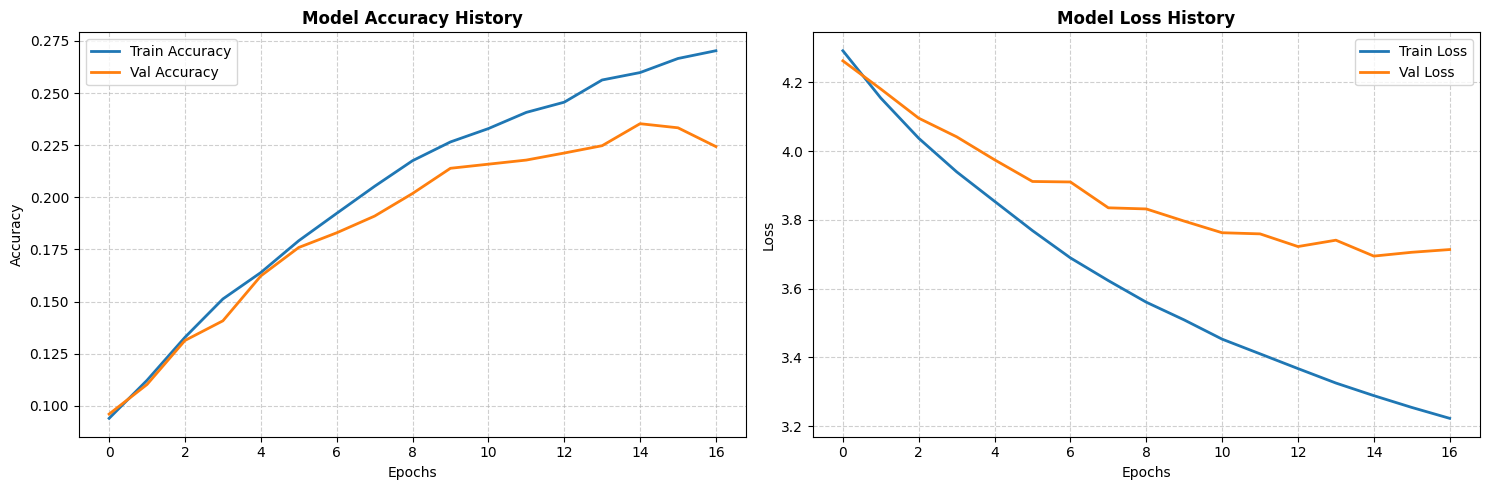

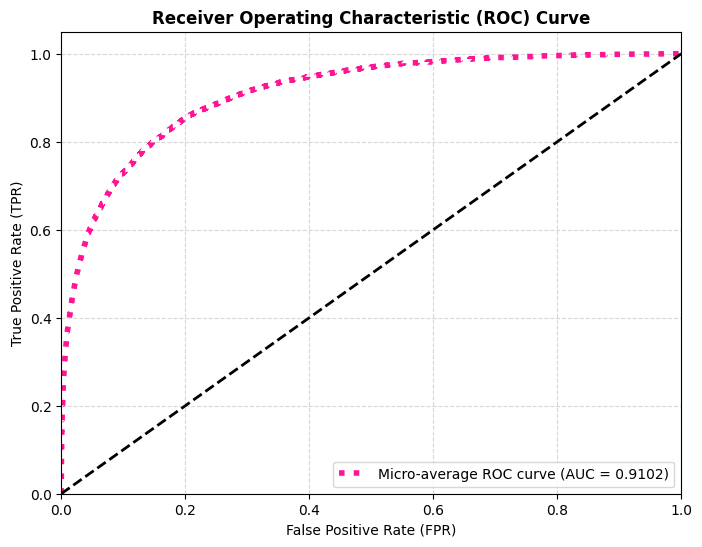

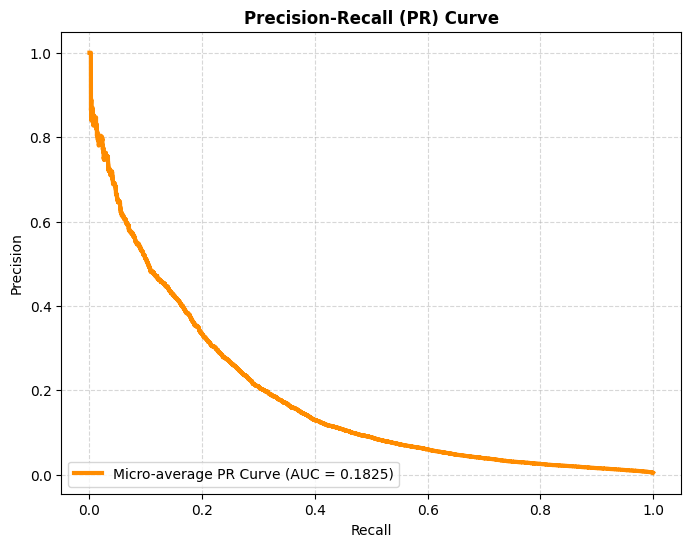

IndexError: index 197 is out of bounds for axis 0 with size 196

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

print("Evaluating model on test data... (This might take a few minutes as it processes test spectrograms)")

# 1. Test Dataset se True Labels aur Predictions nikalna
y_true = []
y_pred_probs = []

# Test loader se batch-by-batch data process karna
for images, labels in test_loader:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# 2. Textual Classification Report (Precision, Recall, F1-Score, Accuracy)
print("\n" + "="*60)
print("--- DETAILED CLASSIFICATION REPORT ---")
print("="*60)
# zero_division=0 lagaya taaki jin classes ke liye predictions nahi aayi unpar error na aaye
print(classification_report(y_true, y_pred_labels, digits=4, zero_division=0))

print("\n" + "="*60)
print("--- GENERATING PERFORMANCE GRAPHS ---")
print("="*60)

# 3. GRAPH 1: Training & Validation History (Loss & Accuracy)
# (Yeh tabhi chalega agar aapne 'hist' variable me training save ki hai)
if 'hist' in globals() and hasattr(hist, 'history'):
    plt.figure(figsize=(15, 5))
    
    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(hist.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Model Accuracy History', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(hist.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
    plt.title('Model Loss History', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Multi-class setup for ROC and Precision-Recall Curves
n_classes = classification_num  # 206 classes
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

# 4. GRAPH 2: Multi-class ROC-AUC Curve (Macro & Micro Average)
fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute Micro-average ROC curve
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC curve (AUC = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle=':', linewidth=4)

# Plot reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. GRAPH 3: Precision-Recall Curve (Micro Average)
precision = dict()
recall = dict()
pr_auc = dict()

precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_binarized.ravel(), y_pred_probs.ravel())
pr_auc["micro"] = auc(recall["micro"], precision["micro"])

plt.figure(figsize=(8, 6))
plt.plot(recall["micro"], precision["micro"], 
         color='darkorange', linewidth=3,
         label=f'Micro-average PR Curve (AUC = {pr_auc["micro"]:.4f})')
plt.title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 6. GRAPH 4: Confusion Matrix (Top 20 most frequent classes for readability)
# Kyuki 206 classes ka confusion matrix bohot khichdi ban jayega, hum test set ki top 20 classes ka dikhayenge
sample_classes = np.bincount(y_true).argsort()[-20:]  # Top 20 most frequent classes in test set

cm = confusion_matrix(y_true, y_pred_labels)
cm_subset = cm[np.ix_(sample_classes, sample_classes)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sample_classes, yticklabels=sample_classes)
plt.title('Confusion Matrix (Subset of Top 20 Classes)', fontsize=14, fontweight='bold')
plt.ylabel('True Bird Class')
plt.xlabel('Predicted Bird Class')
plt.show()